In [55]:
# !pip install anomalib
# !pip install matplotlib
# !pip install numpy
# !pip install tensorboard
# !pip install torch==2.7.1 torchvision==0.22.1 torchaudio==2.7.1 --index-url https://download.pytorch.org/whl/cu128
# !pip install kaggle

In [56]:
# 2. Импорт необходимых модулей
import os
import copy
import re
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import json
import random
from sklearn.model_selection import train_test_split
from pathlib import Path

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.optim as optim
import torch.nn.functional as torch_f
import torch.nn as nn

from anomalib.models.image.fastflow.loss import FastflowLoss
from anomalib.models.image.fastflow.torch_model import FastflowModel

from sklearn.metrics import confusion_matrix
import cv2
from skimage import data, filters, measure
from skimage.segmentation import clear_border
# import warnings
# warnings.filterwarnings('ignore')

In [57]:
run_note = """
Цель запуска: Добавление расширенной аугментации.
Ключевые настройки: Модель FastFlow с backbone ResNet18, 10 flow steps, 8 эпох, learning rate 1e-5, weight decay 5e-5, eta_min 1e-6, batch size 32, расширение аугментаций (GaussianBlur, RandomErasing). Размер тренировочного датасета - 1000 изображений.
Комментарий: Предполагается, что аугментация позволит моедли лучше обобщать детали, поскольку тренировочный датасет не покрывает всё разнообразие деталей.
""".strip()


def save_run_note(log_dir, filename="run_note.txt"):
    os.makedirs(log_dir, exist_ok=True)
    with open(os.path.join(log_dir, filename), "w", encoding="utf-8") as f:
        f.write(run_note.strip() + "\n")


# Сборка датасетов

Для предобработки картинок и постобработки карт аномалий

In [58]:
def resolve_project_path(*parts):
    relative = Path(*parts)
    cwd = Path.cwd().resolve()
    candidates = [cwd / relative, cwd.parent / relative]
    for candidate in candidates:
        if candidate.exists():
            return str(candidate)
    return str(candidates[0])


dataset_path = resolve_project_path("datasets", "processed_printer_dataset")
image_size = 256
random_seed = 42

# Same train/validation dates and caps as SuperSimpleNet_printer.ipynb.
train_date_names = [
    "2024-12-16",
    "2025-01-15",
    "2025-01-29",
    "2025-04-02",
    "2025-05-26",
    "2025-05-28",
]
validation_date_names = ["2025-02-07_test", "2025-06-25_test"]
max_train_images = 1000
max_val_images = 160
max_train_images_per_date = 250
max_val_images_per_date = 100
max_test_good_images = None
max_test_anomaly_images = None
test_visualization_per_class = 5
coordinate_bin_size = 512
num_train_epochs = 8


In [59]:
def get_augmented_transformer(image_size):
    return transforms.Compose([
        transforms.RandomResizedCrop((image_size, image_size), scale=(0.3, 2.), ratio=(0.3, 2.)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=90),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.RandomApply(torch.nn.ModuleList([
            transforms.GaussianBlur(kernel_size=3, sigma=(0.5, 1.3)),
        ]), p=0.8),
        # transforms.GaussianBlur(kernel_size=5, sigma=(0.05, 1.2)),
        transforms.ToTensor(),
        transforms.RandomErasing(
            p=0.4,
            scale=(0.02, 0.4),
            ratio=(0.1, 5.),
            value=0,
            inplace=False
        ),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

def get_transformer(image_size):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

def show_tensor(tensor):
    pil_img = transforms.ToPILImage()
    pil_img(tensor).show()


def postprocess_anomaly_map(anomaly_map, true_img_size):
    ndims = anomaly_map.ndim
    while anomaly_map.ndim < 4:
        anomaly_map = anomaly_map.unsqueeze(0)

    upsampled_mask = torch_f.interpolate(
        anomaly_map,
        size=true_img_size,
        mode='bilinear',
        align_corners=False
    )
    
    return upsampled_mask.squeeze()

In [60]:
# path = os.path.join(dataset_path, class_name, "test", test_groups[0], "003.png")
# print(path)
# img = Image.open(path).convert('RGB')
# img = get_transformer(image_size)(img)
# print(img.shape)
# # img = img[0, :, :]
# img = postprocess_anomaly_map(img.unsqueeze(0), true_img_size=(900, 900))
# print(img.shape)
# print(img.max())
# print(img.dtype)
# show_tensor(img)

Датасеты

In [61]:
IMAGE_EXTENSIONS = (".png", ".jpg", ".jpeg")


def is_image_file(name):
    return str(name).lower().endswith(IMAGE_EXTENSIONS) and not os.path.basename(str(name)).startswith("._")


def list_image_files(root_dir, recursive=False):
    if not os.path.isdir(root_dir):
        return []
    if recursive:
        paths = []
        for current_dir, _, files in os.walk(root_dir):
            paths.extend(os.path.join(current_dir, name) for name in sorted(files) if is_image_file(name))
        return sorted(paths)
    return sorted(os.path.join(root_dir, name) for name in os.listdir(root_dir) if is_image_file(name))


def parse_fragment_name(path, coord_bin_size=512):
    stem = os.path.splitext(os.path.basename(path))[0]
    parts = stem.split("_")
    frame_id = parts[0] if parts else stem
    object_id = "whole"
    for part in parts:
        if part.startswith("obj") and part[3:].isdigit():
            object_id = part
            break

    coord_bin = (-1, -1)
    if "tile" in parts:
        tile_idx = parts.index("tile")
        if tile_idx + 2 < len(parts) and parts[tile_idx + 1].isdigit() and parts[tile_idx + 2].isdigit():
            x = int(parts[tile_idx + 1])
            y = int(parts[tile_idx + 2])
            coord_bin = (x // coord_bin_size, y // coord_bin_size)
    return frame_id, object_id, coord_bin


def diverse_sample_paths(paths, max_items=None, seed=42, salt="", coord_bin_size=512):
    paths = sorted(paths)
    if max_items is None or len(paths) <= max_items:
        return paths

    rng = random.Random(f"{seed}_{salt}")
    grouped = {}
    for path in paths:
        frame_id, object_id, coord_bin = parse_fragment_name(path, coord_bin_size=coord_bin_size)
        grouped.setdefault((frame_id, object_id), {}).setdefault(coord_bin, []).append(path)

    group_keys = sorted(grouped)
    rng.shuffle(group_keys)
    queues = {}
    for group_key in group_keys:
        coord_keys = sorted(grouped[group_key])
        rng.shuffle(coord_keys)
        queue = []
        for coord_key in coord_keys:
            coord_paths = sorted(grouped[group_key][coord_key])
            rng.shuffle(coord_paths)
            queue.extend(coord_paths)
        queues[group_key] = queue

    selected = []
    while len(selected) < max_items and queues:
        for group_key in list(group_keys):
            queue = queues.get(group_key)
            if not queue:
                queues.pop(group_key, None)
                continue
            selected.append(queue.pop(0))
            if len(selected) >= max_items:
                break
    return sorted(selected)


class Train_Dataset(Dataset):
    def __init__(self, root_dir, anomalies_dir="anomalies", transform=None, include_dates=None, exclude_dates=None, max_images=None, max_images_per_date=None, seed=42, coord_bin_size=512):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.dates = []
        include_dates = set(include_dates) if include_dates is not None else None
        exclude_dates = set(exclude_dates) if exclude_dates is not None else set()
        
        for date_dir in sorted(os.listdir(self.root_dir)):
            if date_dir == anomalies_dir:
                continue
            if include_dates is not None and date_dir not in include_dates:
                continue
            if date_dir in exclude_dates:
                continue

            objects_dir = os.path.join(self.root_dir, date_dir, "objects_parts")
            date_image_paths = diverse_sample_paths(
                list_image_files(objects_dir),
                max_items=max_images_per_date,
                seed=seed,
                salt=date_dir,
                coord_bin_size=coord_bin_size,
            )
            self.image_paths.extend(date_image_paths)
            self.dates.extend([date_dir] * len(date_image_paths))

        if max_images is not None and len(self.image_paths) > max_images:
            selected = set(diverse_sample_paths(
                self.image_paths,
                max_items=max_images,
                seed=seed,
                salt="total_train_subset",
                coord_bin_size=coord_bin_size,
            ))
            self.image_paths, self.dates = zip(*[
                (path, date) for path, date in zip(self.image_paths, self.dates) if path in selected
            ])
            self.image_paths = list(self.image_paths)
            self.dates = list(self.dates)
        
        print(f"Loaded {len(self.image_paths)} object fragments from {self.root_dir}")
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image


def get_date_split(root_dir, validation_fraction=0.2):
    dates = []
    for date_dir in sorted(os.listdir(root_dir)):
        objects_dir = os.path.join(root_dir, date_dir, "objects_parts")
        if os.path.isdir(objects_dir):
            dates.append(date_dir)

    val_count = max(1, int(round(len(dates) * validation_fraction)))
    val_dates = dates[-val_count:]
    train_dates = dates[:-val_count]
    return train_dates, val_dates


def anomaly_index_from_name(name):
    match = re.fullmatch(r"anomaly_(\d+)\.(png|jpg|jpeg)", name.lower())
    return int(match.group(1)) if match else None


def is_good_visual_image(name):
    return re.fullmatch(r"good_\d+\.(png|jpg|jpeg)", name.lower()) is not None


def is_visual_test_anomaly(name, max_index=16):
    anomaly_index = anomaly_index_from_name(name)
    return anomaly_index is not None and anomaly_index <= max_index


def is_head_finetune_anomaly(name, min_index=17):
    anomaly_index = anomaly_index_from_name(name)
    return anomaly_index is not None and anomaly_index >= min_index


def is_visual_test_image(name):
    return is_good_visual_image(name) or is_visual_test_anomaly(name)
    

class Validation_Dataset(Dataset):
    def __init__(self, root_dir, transform=None, return_names=False, filename_filter=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.return_names = return_names
        for img_name in sorted(os.listdir(root_dir)):
            if not img_name.lower().endswith((".png", ".jpg", ".jpeg")):
                continue
            if filename_filter is not None and not filename_filter(img_name):
                continue
            self.image_paths.append(os.path.join(root_dir, img_name))
        
        print(f"Loaded {len(self.image_paths)} object fragments from {self.root_dir}")
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        if self.return_names:
            return image, os.path.basename(self.image_paths[idx])
        else:
            return image


class Test_Classification_Dataset(Dataset):
    def __init__(self, test_root, transform=None, max_good_images=None, max_anomaly_images=None, seed=42, coord_bin_size=512):
        self.transform = transform
        good_paths = diverse_sample_paths(
            list_image_files(os.path.join(test_root, "good")),
            max_items=max_good_images,
            seed=seed,
            salt="test_good",
            coord_bin_size=coord_bin_size,
        )
        anomaly_paths = diverse_sample_paths(
            list_image_files(os.path.join(test_root, "anomalies")),
            max_items=max_anomaly_images,
            seed=seed,
            salt="test_anomalies",
            coord_bin_size=coord_bin_size,
        )
        self.samples = (
            [(path, 0, "good", f"good_{os.path.basename(path)}") for path in good_paths]
            + [(path, 1, "printer_anomaly", f"anomaly_{os.path.basename(path)}") for path in anomaly_paths]
        )
        self.labels = [sample[1] for sample in self.samples]
        print(
            "Loaded test classification dataset: "
            f"good={sum(label == 0 for label in self.labels)}, anomaly={sum(label == 1 for label in self.labels)}"
        )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label, defect_type, name = self.samples[idx]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label, defect_type, name


class Classification_Visualization_Dataset(Dataset):
    def __init__(self, classification_dataset, per_class=5):
        self.classification_dataset = classification_dataset
        self.indices = []
        counts = {0: 0, 1: 0}
        for idx, label in enumerate(classification_dataset.labels):
            if counts[label] < per_class:
                self.indices.append(idx)
                counts[label] += 1

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, label, _, name = self.classification_dataset[self.indices[idx]]
        return image, name


In [62]:
train_root = os.path.join(dataset_path, "training")
test_root = os.path.join(dataset_path, "test")
train_dates = train_date_names
val_dates = validation_date_names
print(f"Train dates: {train_dates}")
print(f"Validation dates: {val_dates}")

train_dataset = Train_Dataset(
    train_root,
    transform=get_augmented_transformer(image_size),
    include_dates=train_dates,
    max_images=max_train_images,
    max_images_per_date=max_train_images_per_date,
    seed=random_seed,
    coord_bin_size=coordinate_bin_size,
)

normal_val_dataset = Train_Dataset(
    train_root,
    transform=get_transformer(image_size),
    include_dates=val_dates,
    max_images=max_val_images,
    max_images_per_date=max_val_images_per_date,
    seed=random_seed,
    coord_bin_size=coordinate_bin_size,
)

classification_test_dataset = Test_Classification_Dataset(
    test_root,
    transform=get_transformer(image_size),
    max_good_images=max_test_good_images,
    max_anomaly_images=max_test_anomaly_images,
    seed=random_seed,
    coord_bin_size=coordinate_bin_size,
)
visualization_dataset = Classification_Visualization_Dataset(classification_test_dataset, per_class=test_visualization_per_class)
print(visualization_dataset[0][0].shape, visualization_dataset[0][1])
print(f"Train images: {len(train_dataset)}")
print(f"Normal validation images: {len(normal_val_dataset)}")
print(f"Classification test images: {len(classification_test_dataset)}")
print(f"Visual test images: {len(visualization_dataset)}")


Train dates: ['2024-12-16', '2025-01-15', '2025-01-29', '2025-04-02', '2025-05-26', '2025-05-28']
Validation dates: ['2025-02-07_test', '2025-06-25_test']
Loaded 1000 object fragments from C:\Users\AERO\Desktop\master_work\Experiments\datasets\processed_printer_dataset\training
Loaded 160 object fragments from C:\Users\AERO\Desktop\master_work\Experiments\datasets\processed_printer_dataset\training
Loaded test classification dataset: good=37, anomaly=46
torch.Size([3, 256, 256]) good_103_obj23_tile_3404_2243.png
Train images: 1000
Normal validation images: 160
Classification test images: 83
Visual test images: 10


In [63]:
from PIL import Image
import torch
import numpy as np

def tensor_to_image(tensor):
    tensor = tensor.cpu().detach()
    denormalize = transforms.Compose([
        transforms.Normalize(mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225], std=[1/0.229, 1/0.224, 1/0.225])
    ])
    tensor = denormalize(tensor)
    if tensor.dim() == 3:
        if tensor.size(0) == 1:
            tensor = tensor.squeeze(0)
        else:
            tensor = tensor.permute(1, 2, 0)
    
    img_np = tensor.numpy()

    if img_np.max() <= 1.0:
        img_np = (img_np * 255).astype(np.uint8)
    else:
        img_np = img_np.astype(np.uint8)

    if len(img_np.shape) == 2:
        return Image.fromarray(img_np, mode='L')
    else:
        return Image.fromarray(img_np)
    
print(train_dataset[0].shape)
tensor_to_image(train_dataset[0]).save("test_img.png")

torch.Size([3, 256, 256])


In [64]:
def test_images_quality(images_count=3, random_seed=42):
    os.makedirs("./test_normal_images", exist_ok=True)
    print("used existed folder")
    random.seed(random_seed)
    for i, tensor in enumerate(random.choices(train_dataset, k=images_count)):
        tensor_to_image(tensor).save(f"./test_normal_images/img_{i}.png")
test_images_quality()

used existed folder


# Метрики качества

In [65]:
import numpy as np
from sklearn.metrics import average_precision_score, roc_auc_score, roc_auc_score
import cv2
import matplotlib.pyplot as plt
from skimage import measure

def img2mask(img):
    mask = img if img.ndim <= 2 else img.squeeze()
    if mask.ndim == 3:
        mask = mask[0, :, :]
    if mask.ndim != 2:
        print("Wrong dimensions")
        raise ValueError
    return mask

def pixel_avg_precision(pred_anomaly_map, true_mask):
    pred_anomaly_map = img2mask(pred_anomaly_map)
    true_mask = img2mask(true_mask)

    y_true = (true_mask.flatten().cpu().numpy() > 0.5).astype(int)
    y_scores = pred_anomaly_map.flatten().cpu().numpy()

    if y_scores.max() > 1.0 or y_scores.min() < 0.0:
        print(f"predicted masks scores are not from [0, 1]")
        raise ValueError

    ap = average_precision_score(y_true, y_scores)
    return ap if not np.isnan(ap) else 0.0


def pixel_roc_auc(pred_anomaly_map, true_mask):
    pred_anomaly_map = img2mask(pred_anomaly_map)
    true_mask = img2mask(true_mask)

    y_true = (true_mask.flatten().cpu().numpy() > 0.5).astype(int)
    y_scores = pred_anomaly_map.flatten().cpu().numpy()

    if y_scores.max() > 1.0 or y_scores.min() < 0.0:
        print(f"predicted masks scores are not from [0, 1]")
        raise ValueError

    auc = roc_auc_score(y_true, y_scores)
    return auc if not np.isnan(auc) else 0.5


def predict_label(pred_anomaly_map, k=0.001):
    """Возвращает скор картинки по среднему k наибольших пикселей"""
    pred_anomaly_map = img2mask(pred_anomaly_map)

    y_scores = pred_anomaly_map.flatten().cpu()
    top_k_scores = torch.topk(y_scores, int(k * len(y_scores)))

    return torch.mean(top_k_scores.values)


def evaluate_classification_dataset(model, dataset, device=None):
    eval_device = device if device is not None else globals().get("device", "cuda" if torch.cuda.is_available() else "cpu")
    rows = []
    labels = []
    scores = []
    model.eval()
    with torch.no_grad():
        for i in tqdm(range(len(dataset)), desc="Classification Eval", leave=False):
            img, true_label, defect_type, name = dataset[i]
            img = img.unsqueeze(0).to(eval_device)
            anomaly_map = postprocess_anomaly_map(
                predict_anomaly_map(model, img),
                true_img_size=(image_size, image_size)
            )
            score = float(predict_label(anomaly_map).detach().cpu())
            labels.append(int(true_label))
            scores.append(score)
            rows.append({
                "index": i,
                "name": name,
                "defect_type": defect_type,
                "true_label": int(true_label),
                "score": score,
                "pred_label_at_0_5": int(score >= 0.5),
            })

    metrics = {
        "num_good": int(sum(label == 0 for label in labels)),
        "num_anomaly": int(sum(label == 1 for label in labels)),
        "accuracy_at_0_5": float(np.mean([row["pred_label_at_0_5"] == row["true_label"] for row in rows])),
    }
    metrics["image_roc_auc_raw"] = roc_auc_score(labels, scores) if len(set(labels)) > 1 else float("nan")
    good_scores = np.array([score for score, label in zip(scores, labels) if label == 0], dtype=float)
    anomaly_scores = np.array([score for score, label in zip(scores, labels) if label == 1], dtype=float)
    pooled_std = np.sqrt((good_scores.var() + anomaly_scores.var()) / 2) if len(good_scores) and len(anomaly_scores) else 0.0
    metrics["score_separation_cohens_d_raw"] = float((anomaly_scores.mean() - good_scores.mean()) / pooled_std) if pooled_std > 0 else float("nan")
    return metrics, rows


def write_classification_eval(metrics, rows, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    with open(os.path.join(output_dir, "metrics.txt"), "w") as f:
        for metric_name, metric_value in metrics.items():
            f.write(f"{metric_name}: {metric_value}\n")
    with open(os.path.join(output_dir, "rows.csv"), "w") as f:
        f.write("index,name,defect_type,true_label,score,pred_label_at_0_5\n")
        for row in rows:
            f.write(
                f"{row['index']},{row['name']},{row['defect_type']},{row['true_label']},"
                f"{row['score']},{row['pred_label_at_0_5']}\n"
            )


def plot_training_curves(metrics: list, metric_names: list, log_dir: str, plot_name: str, log_y=False):
    os.makedirs(log_dir, exist_ok=True)

    plt.figure(figsize=(10, 6))
    for metric, metric_name in zip(metrics, metric_names):
        plt.plot(metric, label=metric_name, marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Metric')
    if log_y:
        plt.yscale('log')
    plt.title(f'Training and Validation {metric_name}')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(log_dir, plot_name))
    plt.show()


def predict_anomaly_map(model, img, true_img_size=None, augmentations=False):
    aug_anomaly_maps = []
    
    with torch.no_grad():
        anomaly_map = model(img).anomaly_map + 1.
        aug_anomaly_maps.append(anomaly_map)
    
    if augmentations:
        with torch.no_grad():
            img_flip_h = torch.flip(img, dims=[-1])
            anomaly_map_flip_h = model(img_flip_h).anomaly_map + 1.
            anomaly_map_flip_h = torch.flip(anomaly_map_flip_h, dims=[-1])
            aug_anomaly_maps.append(anomaly_map_flip_h)
        
        with torch.no_grad():
            img_flip_v = torch.flip(img, dims=[-2])
            anomaly_map_flip_v = model(img_flip_v).anomaly_map + 1.
            anomaly_map_flip_v = torch.flip(anomaly_map_flip_v, dims=[-2])
            aug_anomaly_maps.append(anomaly_map_flip_v)
    
    avg_anomaly_map = torch.mean(torch.stack(aug_anomaly_maps), dim=0)
    
    if true_img_size is not None:
        avg_anomaly_map = postprocess_anomaly_map(avg_anomaly_map, true_img_size=true_img_size)
    
    return avg_anomaly_map


def visualize_results(original_image, anomaly_map, image_size, true_mask=None, save_path=None, score=None, figsize=(15, 5), alpha=0.7, cmap='jet'):
    denormalize = transforms.Compose([
        transforms.Normalize(mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225], std=[1/0.229, 1/0.224, 1/0.225])
    ])
    original_image = denormalize(original_image)
    original_image = postprocess_anomaly_map(original_image, true_img_size=(image_size, image_size))
    original_image = original_image if original_image.ndim <= 3 else original_image.squeeze()
    if anomaly_map is not None:
        anomaly_map = anomaly_map if anomaly_map.ndim <= 3 else anomaly_map.squeeze()

    to_pil = transforms.ToPILImage()
    if isinstance(original_image, torch.Tensor):
        original_image = to_pil(original_image)

    n_sections = 1 + int(true_mask is not None) + int(anomaly_map is not None)
    section_figsize = (figsize[0] * n_sections / 3, figsize[1])
    fig, axes = plt.subplots(1, n_sections, figsize=section_figsize)
    if n_sections == 1:
        axes = [axes]
    section_idx = 0
    
    # Оригинальное изображение
    axes[section_idx].imshow(original_image)
    axes[section_idx].set_title('Original image', fontsize=14)
    axes[section_idx].axis('off')
    section_idx += 1
    
    # Маска
    if not (true_mask is None):
        true_mask = true_mask if true_mask.ndim <= 3 else true_mask.squeeze()
        true_mask = img2mask(true_mask)
        if isinstance(true_mask, torch.Tensor):
            true_mask = true_mask.cpu().numpy()
        axes[section_idx].imshow(original_image)
        heatmap = axes[section_idx].imshow(true_mask, cmap=cmap, alpha=alpha, vmin=0., vmax=1.)
        axes[section_idx].set_title('Input + True Mask', fontsize=14)
        axes[section_idx].axis('off')
        plt.colorbar(heatmap, ax=axes[section_idx], fraction=0.046, pad=0.04)
        section_idx += 1


    # Карта аномалий
    if anomaly_map is not None:
        anomaly_map = img2mask(anomaly_map)
        if isinstance(anomaly_map, torch.Tensor):
            anomaly_map = anomaly_map.squeeze().cpu().numpy()

        axes[section_idx].imshow(original_image)
        heatmap = axes[section_idx].imshow(anomaly_map, cmap=cmap, alpha=alpha, vmin=0., vmax=1.)
        axes[section_idx].set_title('Input + Anomaly Map', fontsize=14)
        axes[section_idx].axis('off')
        plt.colorbar(heatmap, ax=axes[section_idx], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    if save_path is None:
        plt.show()
    else:
        plt.savefig(save_path)
        plt.close()

# Обучение модели

In [66]:
device="cuda" if torch.cuda.is_available() else "cpu"
print(device)
print(f"Название GPU: {torch.cuda.get_device_name(torch.cuda.current_device())}")

cuda
Название GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU


In [67]:
def freeze_feature_extractor(model):
    """Замораживает веса предобученного экстрактора фичей"""
    frozen_params_num = 0
    if hasattr(model, 'feature_extractor'):
        for param in model.feature_extractor.parameters():
            param.requires_grad = False
            frozen_params_num += param.numel()
    print(f"Parameters frozen: {frozen_params_num}")

def get_trainable_parameters(model):
    """Возвращает список обучаемых параметров"""
    trainable_params = []
    train_params_num = 0
    for name, param in model.named_parameters():
        if param.requires_grad:
            trainable_params.append(param)
            train_params_num += param.numel()
    print(f"Trainable parameters: {train_params_num}")
    return trainable_params

In [68]:
import torch
import torch.nn as nn
from torch.optim import Adam, AdamW
from torch.utils.data import DataLoader
from tqdm import tqdm
import os
import copy
import numpy as np
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

def train_fastflow_with_validation(
    model,
    train_dataset,
    validation_dataset,
    visualization_dataset=None,
    num_epochs=10,
    learning_rate=1e-3,
    weight_decay=1e-3,
    eta_min=1e-6,
    device=device,
    log_interval=1,
    log_dir="../experiments",
    freeze_extractor=True,
    batch_size=8,
    num_workers=0,
    resume_from_checkpoint=False,
    early_stopping_patience=5,
    early_stopping_metric="Val_Loss",
    early_stopping_mode="min"
):
    model = model.to(device)
    criterion = FastflowLoss()
    os.makedirs(log_dir, exist_ok=True)
    checkpoints_dir = os.path.join(log_dir, "middle_logs")
    os.makedirs(checkpoints_dir, exist_ok=True)

    print(f"Training samples: {len(train_dataset)}, Validation samples: {len(validation_dataset)}")

    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters number: {total_params}")
    if freeze_extractor:
        freeze_feature_extractor(model)
    trainable_params = get_trainable_parameters(model)
    optimizer = optim.AdamW(trainable_params, lr=learning_rate, weight_decay=weight_decay)

    train_loader = DataLoader(
        dataset=train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers
    )
    
    val_loader = DataLoader(
        dataset=validation_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers
    )

    # scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=3 * len(train_loader), T_mult=2, eta_min=1e-11)
    total_steps = num_epochs * len(train_loader)
    warmup_steps = int(0.1 * total_steps)
    warmup_scheduler = LinearLR(
        optimizer,
        start_factor=0.05,
        end_factor=1.0,
        total_iters=warmup_steps
    )
    main_scheduler = CosineAnnealingLR(
        optimizer,
        T_max=max(1, total_steps - warmup_steps),
        eta_min=eta_min
    )
    scheduler = SequentialLR(
        optimizer,
        schedulers=[warmup_scheduler, main_scheduler],
        milestones=[warmup_steps]
    )

    # Early stopping
    best_score = -float('inf') if early_stopping_mode == "max" else float('inf')
    epochs_without_improvement = 0
    best_model_state = None

    checkpoint_path = os.path.join(checkpoints_dir, "checkpoint.pth")
    
    start_epoch = 0
    epoch_scores = {"Train_Loss": [], "Val_Loss": []}
    if resume_from_checkpoint and os.path.exists(checkpoint_path):
        print(f"Loading checkpoint from {checkpoint_path}...")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        if "scheduler_state_dict" in checkpoint:
            scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
        start_epoch = checkpoint["epoch"]
        epoch_scores = checkpoint["epoch_scores"]
        print(f"Resuming from epoch {start_epoch + 1}")
    else:
        print("Starting training from scratch...")

    for epoch in range(start_epoch, num_epochs):
        model.train()
        total_train_loss = 0.0
        for batch in tqdm(train_loader, desc=f"Train Epoch {epoch+1}/{num_epochs}", leave=False):
            if isinstance(batch, (list, tuple)):
                images = batch[0]
            else:
                images = batch
            images = images.to(device)

            optimizer.zero_grad()
            with torch.set_grad_enabled(True):
                outputs = model(images)
                loss = criterion(outputs[0], outputs[1])
                
                loss.backward()
                optimizer.step()
                scheduler.step()
            
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        epoch_scores["Train_Loss"].append(avg_train_loss)

        total_val_loss = 0.0
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Val Epoch {epoch+1}/{num_epochs}", leave=False):
                if isinstance(batch, (list, tuple)):
                    images = batch[0]
                else:
                    images = batch
                images = images.to(device)

                outputs = model(images)
                loss = criterion(outputs[0], outputs[1])
                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        epoch_scores["Val_Loss"].append(avg_val_loss)

        if (epoch + 1) % log_interval == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

            # Визуальная валидация
            if not (visualization_dataset is None):
                model.eval()
                visualization_dir = os.path.join(checkpoints_dir, "visualization", f"epoch_{epoch}")
                os.makedirs(visualization_dir, exist_ok=True)
                with torch.no_grad():
                    for i in range(0, len(visualization_dataset)):
                        img, name = visualization_dataset[i]
                        shapes = img.shape
                        img = img.unsqueeze(0).to(device)
                        
                        anomaly_map = postprocess_anomaly_map(
                            predict_anomaly_map(model, img),
                            true_img_size=(image_size, image_size)
                        )
                        visualize_results(img, anomaly_map, image_size, save_path=os.path.join(visualization_dir, name))

        # Сохранение чекпоинта
        # checkpoint_payload = {
        #     "epoch": epoch + 1,
        #     "model_state_dict": copy.deepcopy(model.state_dict()),
        #     "optimizer_state_dict": optimizer.state_dict(),
        #     "scheduler_state_dict": scheduler.state_dict(),
        #     "epoch_scores": epoch_scores,
        #     "learning_rate": learning_rate,
        # }
        # torch.save(checkpoint_payload, checkpoint_path)
        # torch.save(checkpoint_payload, os.path.join(checkpoints_dir, f"checkpoint_epoch_{epoch + 1}.pth"))

        checkpoint_metrics_path = os.path.join(checkpoints_dir, "checkpoints_metrics.txt")
        if not os.path.exists(checkpoint_metrics_path) or (not resume_from_checkpoint and epoch == 0):
            with open(checkpoint_metrics_path, "w") as f:
                f.write(f"Epoch {epoch + 1}:\n")
                f.write(f"Train_Loss: {avg_train_loss:.6f}\n")
                f.write(f"Val_Loss: {avg_val_loss:.6f}\n")
                f.write("\n")
        else:
            with open(checkpoint_metrics_path, "a") as f:
                f.write(f"Epoch {epoch + 1}:\n")
                f.write(f"Train_Loss: {avg_train_loss:.6f}\n")
                f.write(f"Val_Loss: {avg_val_loss:.6f}\n")
                f.write("\n")
        
        should_stop = False
        if early_stopping_metric in epoch_scores:
            current_score = epoch_scores[early_stopping_metric][-1]

            is_better = (
                (early_stopping_mode == "max" and current_score > best_score) or
                (early_stopping_mode == "min" and current_score < best_score)
            )

            if is_better:
                best_score = current_score
                epochs_without_improvement = 0
                best_model_state = copy.deepcopy(model.state_dict())
                print(f"New best {early_stopping_metric}: {best_score:.6f}")
            else:
                epochs_without_improvement += 1
                print(f"No improvement for {epochs_without_improvement}/{early_stopping_patience} epochs")

            if epochs_without_improvement >= early_stopping_patience:
                print(f"Early stopping triggered at epoch {epoch + 1}")
                should_stop = True
            
        if should_stop:
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Loaded best model (score: {best_score:.6f})")
    else:
        print("No early stopping metric found — using final model")

    torch.save(model.state_dict(), os.path.join(log_dir, "trained_model_weights.pth"))
    torch.save(model, os.path.join(log_dir, "trained_model.pth"))
    print(f"Model saved to {log_dir}")

    with open(os.path.join(log_dir, "final_metrics.txt"), "w") as f:
        f.write(f"Train_Loss: {epoch_scores['Train_Loss'][-1]:.6f}\n")
        f.write(f"Val_Loss: {epoch_scores['Val_Loss'][-1]:.6f}\n")
        f.write(f"Best_Val_Loss: {best_score:.6f}\n")

    plot_training_curves([epoch_scores["Train_Loss"], epoch_scores["Val_Loss"]], 
                        ["Train_Loss", "Val_Loss"], 
                        log_dir, "train_val_loss.png")

    return model

In [69]:
torch.cuda.empty_cache()

Training samples: 1000, Validation samples: 160
Total parameters number: 8661888
Parameters frozen: 2782784
Trainable parameters: 4158784
Starting training from scratch...


Train Epoch 1/8:  75%|███████▌  | 24/32 [00:16<00:05,  1.34it/s]c:\Users\AERO\Desktop\master_work\Experiments\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:198: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 1/8 | Train Loss: 222459.257324 | Val Loss: 198675.421875
New best Val_Loss: 198675.421875


Epoch 2/8 | Train Loss: 161192.472168 | Val Loss: 129323.128125
New best Val_Loss: 129323.128125


Epoch 3/8 | Train Loss: 87585.891602 | Val Loss: 60530.475000
New best Val_Loss: 60530.475000


Epoch 4/8 | Train Loss: 18573.795975 | Val Loss: 5455.556152
New best Val_Loss: 5455.556152


Epoch 5/8 | Train Loss: -36683.987488 | Val Loss: -30949.090039
New best Val_Loss: -30949.090039


Epoch 6/8 | Train Loss: -70542.740967 | Val Loss: -52608.242969
New best Val_Loss: -52608.242969


Epoch 7/8 | Train Loss: -91492.424072 | Val Loss: -63708.739062
New best Val_Loss: -63708.739062


Epoch 8/8 | Train Loss: -101399.997559 | Val Loss: -69701.035937
New best Val_Loss: -69701.035937
Loaded best model (score: -69701.035937)
Model saved to C:\Users\AERO\Desktop\master_work\Experiments\experiments\printer\fastflow_resnet18\try_2


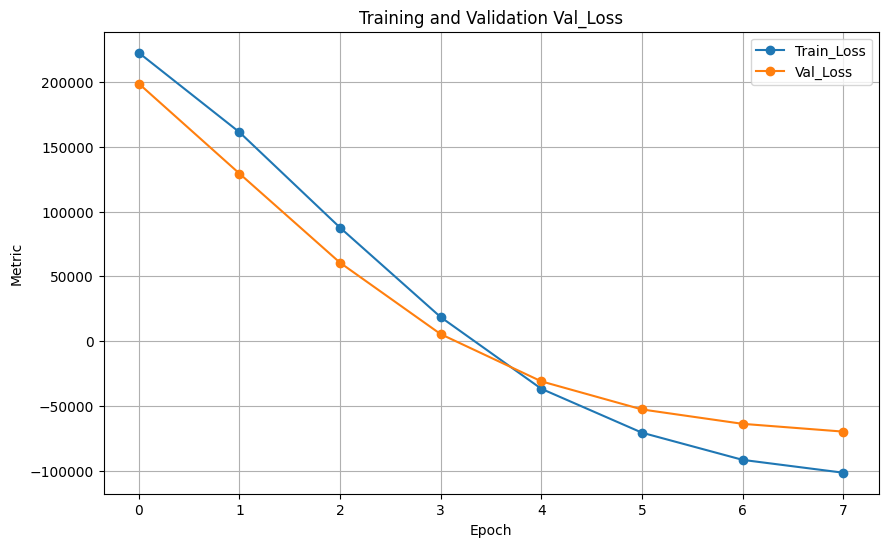

In [70]:
model = FastflowModel(
        backbone="resnet18",
        flow_steps=10,
        input_size=[image_size, image_size],
        pre_trained=True
    )

logs_folder = os.path.join("printer", "fastflow_resnet18")
try_number = 2
experiments_root = resolve_project_path("experiments")
log_dir = os.path.join(experiments_root, logs_folder, f"try_{try_number}")
save_run_note(log_dir)
# Тренировка с валидацией
trained_model = train_fastflow_with_validation(
    model=model,
    train_dataset=train_dataset,
    validation_dataset=normal_val_dataset,
    visualization_dataset=visualization_dataset,
    num_epochs=num_train_epochs,
    learning_rate=5e-5,
    weight_decay=5e-5,
    eta_min=5e-6,
    device=device,
    log_dir=log_dir,
    early_stopping_patience=3,
    early_stopping_metric="Val_Loss",
    early_stopping_mode="min",
    batch_size=32
)

In [71]:
torch.cuda.empty_cache()

Подбор гиперпараметров через optuna с Pixel ROC AUC в качестве метрики качества

# Тестирование лучшей обученной модели

In [72]:
device="cuda" if torch.cuda.is_available() else "cpu"
print(device)
print(f"Название GPU: {torch.cuda.get_device_name(torch.cuda.current_device())}")

cuda
Название GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU


In [73]:
anomalies_dataset = visualization_dataset
print(f"Visual test images: {len(anomalies_dataset)}")


Visual test images: 10


In [74]:
print(f"Train images: {len(train_dataset)}")
print(f"Normal validation images: {len(normal_val_dataset)}")


Train images: 1000
Normal validation images: 160


In [75]:
print(anomalies_dataset[0][0].shape)
tensor_to_image(anomalies_dataset[min(10, len(anomalies_dataset) - 1)][0]).save("test_img.png")

torch.Size([3, 256, 256])


num_good: 37
num_anomaly: 46
accuracy_at_0_5: 0.5542168674698795
image_roc_auc_raw: 0.8378378378378378
score_separation_cohens_d_raw: 1.3389000499395967


Anomalous Data Segmentation:   0%|          | 0/10 [00:00<?, ?it/s]

good_103_obj23_tile_3404_2243.png


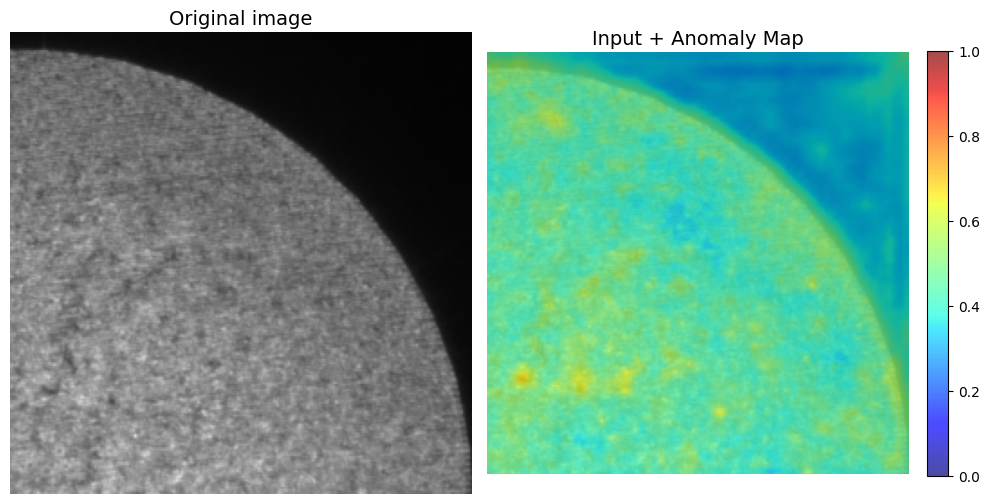

Anomalous Data Segmentation:  10%|█         | 1/10 [00:00<00:02,  4.24it/s]

good_119_obj9_tile_2809_1512.png


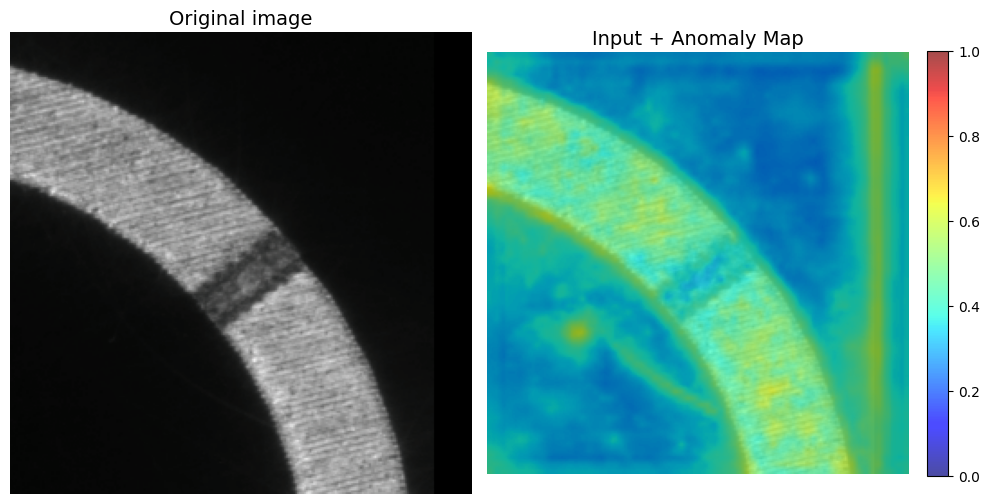

Anomalous Data Segmentation:  20%|██        | 2/10 [00:00<00:01,  4.42it/s]

good_120_obj15_tile_2425_1255.png


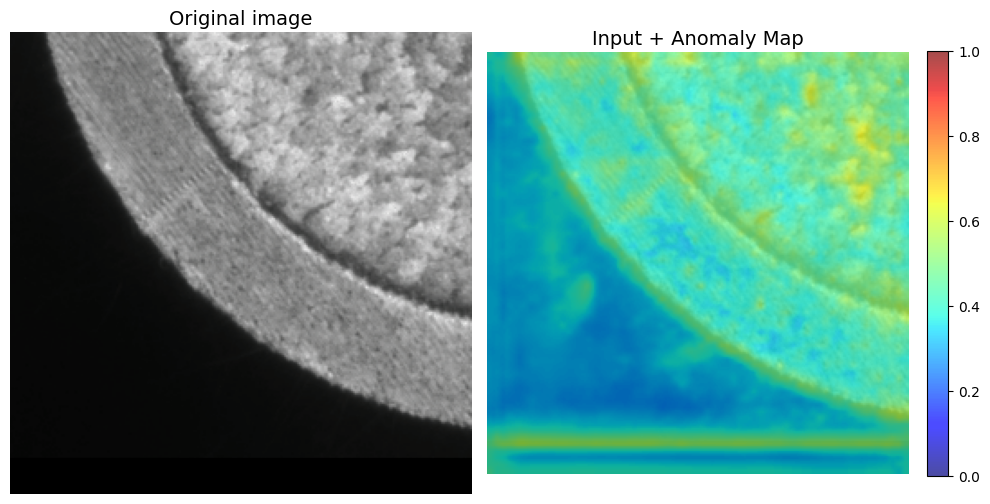

Anomalous Data Segmentation:  30%|███       | 3/10 [00:00<00:01,  4.36it/s]

good_120_obj17_tile_3193_998.png


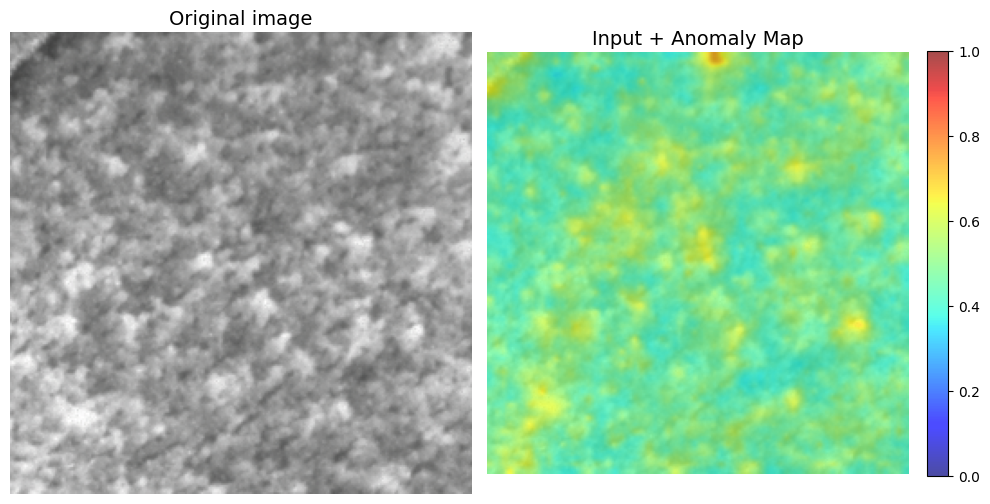

Anomalous Data Segmentation:  40%|████      | 4/10 [00:00<00:01,  4.21it/s]

good_120_obj1_tile_1792_2282.png


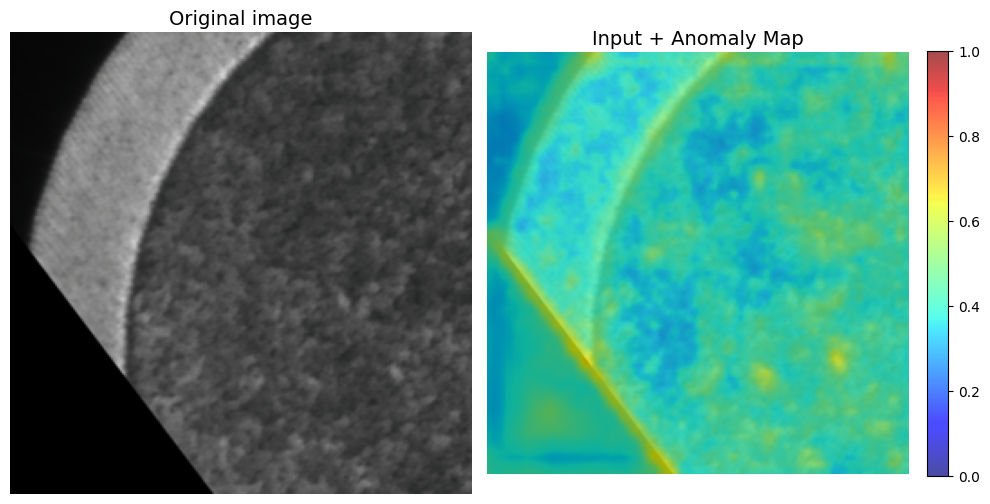

Anomalous Data Segmentation:  50%|█████     | 5/10 [00:01<00:01,  4.19it/s]

anomaly_2025-08-06_11-33-04_L0412_1_tile_1920_2304.png


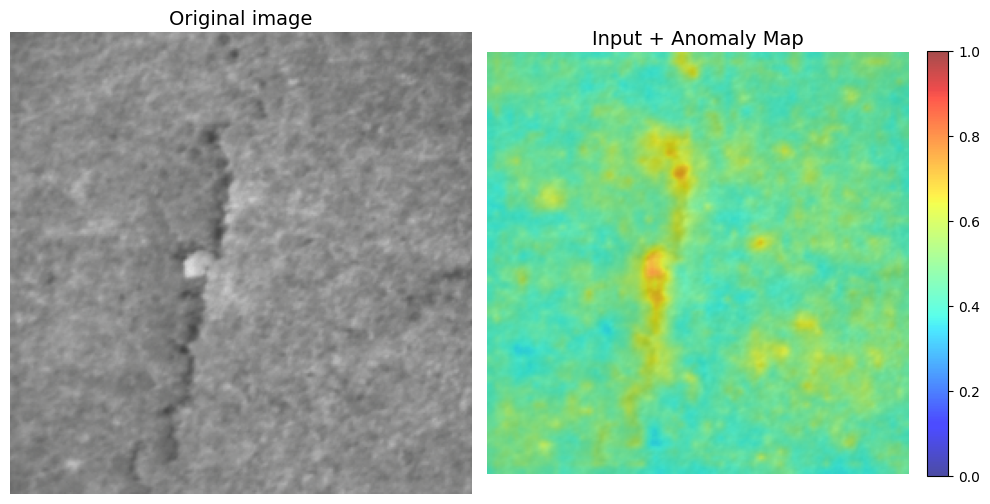

Anomalous Data Segmentation:  60%|██████    | 6/10 [00:01<00:00,  4.13it/s]

anomaly_2025-08-06_11-40-53_L0420_1_tile_1920_2304.png


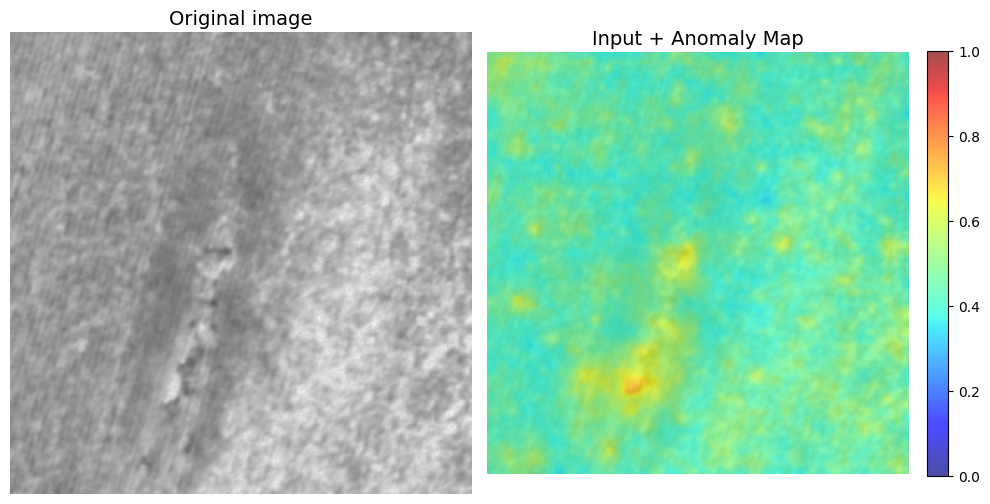

Anomalous Data Segmentation:  70%|███████   | 7/10 [00:01<00:00,  3.95it/s]

anomaly_2025-08-08_14-09-52_L0128_1_tile_1920_1280.png


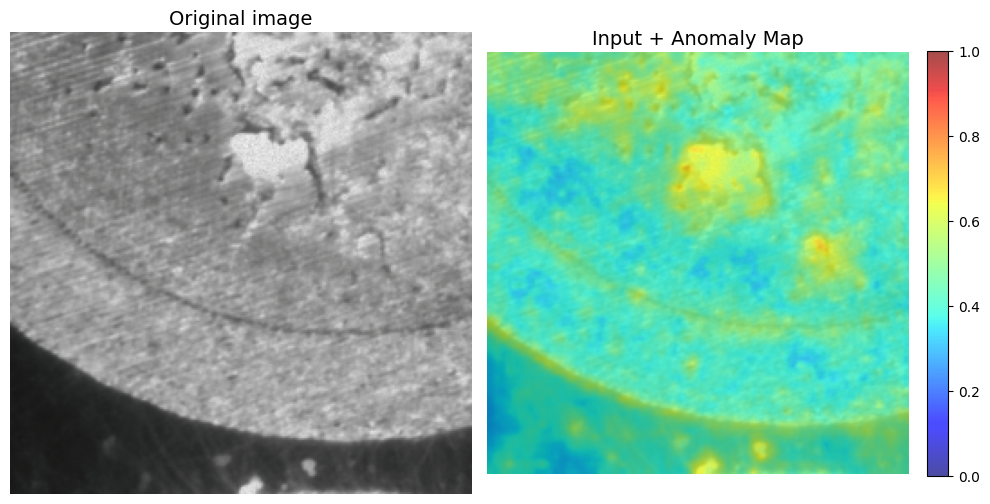

Anomalous Data Segmentation:  80%|████████  | 8/10 [00:01<00:00,  3.95it/s]

anomaly_2025-08-08_14-09-52_L0128_1_tile_2048_1152.png


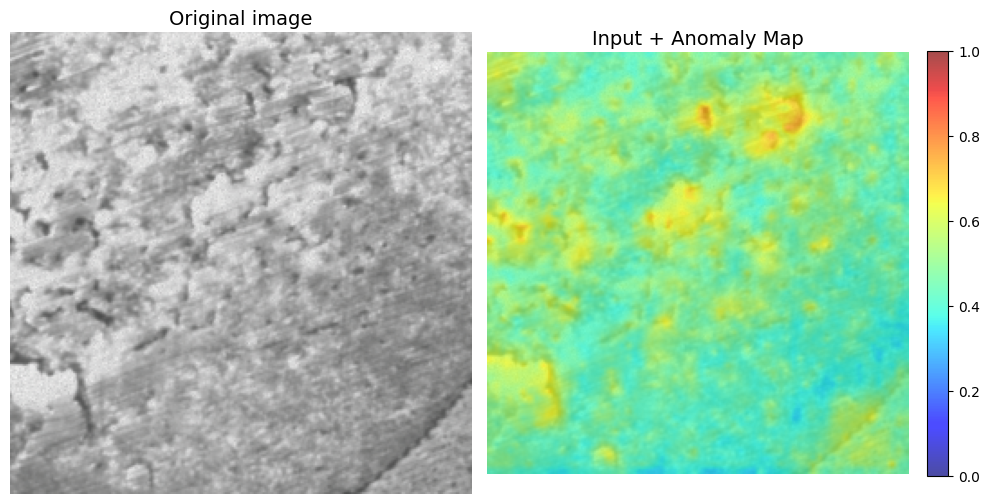

Anomalous Data Segmentation:  90%|█████████ | 9/10 [00:02<00:00,  3.60it/s]

anomaly_2025-08-08_14-09-52_L0128_1_tile_2176_1024.png


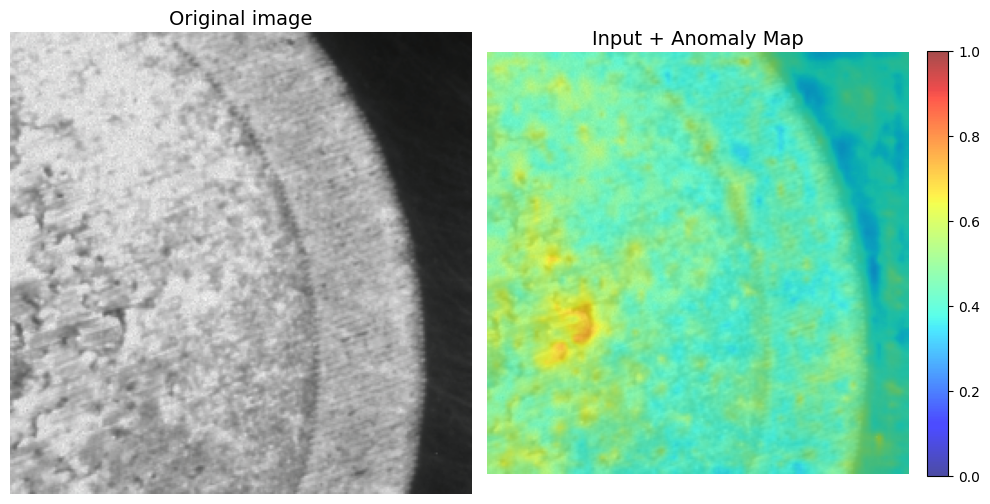

In [76]:
# Загрузка лучшей модели
# best_model_path = os.path.join("../experiments", class_name, "trained_model.pth")
best_model_path = os.path.join(log_dir, "trained_model.pth")
best_trained_model = torch.load(best_model_path, map_location=device, weights_only=False)
best_trained_model.to(device)
best_trained_model.eval()

test_metrics, test_rows = evaluate_classification_dataset(best_trained_model, classification_test_dataset, device=device)
write_classification_eval(test_metrics, test_rows, os.path.join(log_dir, "classification_eval"))
with open(os.path.join(log_dir, "test_metrics.txt"), "w") as f:
    for metric_name, metric_value in test_metrics.items():
        f.write(f"{metric_name}: {metric_value}\n")
for metric_name, metric_value in test_metrics.items():
    print(f"{metric_name}: {metric_value}")

# Тест сегментации на аномальных данных
with torch.no_grad():
    for i in tqdm(range(0, len(anomalies_dataset)), desc="Anomalous Data Segmentation", leave=False):
        img, name = anomalies_dataset[i]
        shapes = img.shape
        img = img.unsqueeze(0).to(device)
        
        anomaly_map = postprocess_anomaly_map(
            predict_anomaly_map(best_trained_model, img), 
            true_img_size=(image_size, image_size)
        )
        print(name)
        visualize_results(img, anomaly_map, image_size)